In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# Метод зеркального спуска

## 1. Постановка задачи

Рассматривается задача выпуклой оптимизации:

$$
\min \left\{ \|Ax - b\|_1 \;:\; x \in \Delta_n \right\},
$$

где:

- $A \in \mathbb{R}^{m \times n}$
- $b \in \mathbb{R}^{m}$
- $\Delta_n = \{x \in \mathbb{R}^n \mid x \ge 0, \sum_{i=1}^n x_i = 1 \}$ — стандартный симплекс.

In [2]:
def ax_b_one_norm_objective(A, b, x):
    return np.linalg.norm(np.dot(A, x) - b, ord=1)


def ax_b_one_norm_objective_subgradient(A, b, x, rng):
    """
    Compute a subgradient of ||Ax - b||₁ at x.
    """
    r = np.dot(A, x) - b
    s = np.sign(r)
    
    zero_tol = 1e-12
    zero_mask = np.abs(r) < zero_tol
    
    if np.any(zero_mask):
        s[zero_mask] = rng.uniform(-1, 1, size=np.sum(zero_mask))
    
    return np.dot(A.T, s)


def generate_ax_b_one_norm_params(n, m, rng):
    A = rng.standard_normal((m, n))
    b = rng.standard_normal(m)

    x = cp.Variable(n, nonneg=True)
    objective = cp.Minimize(cp.norm1(A @ x - b))
    constraints = [cp.sum(x) == 1]
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)
    if problem.status != cp.OPTIMAL and problem.status != cp.OPTIMAL_INACCURATE:
        raise ValueError("CVXPY did not converge")
    x_true = x.value
    
    return A, b, x_true

## 2. Методы оптимизации

Далее $g \in \partial f(x^k)$ - вектор из множества субградиентов функции.

### 2.1 Субградиентный метод с евклидовой проекцией

Работаем в евклидовой норме $\|\cdot\|_2$.

Итерация:

$$
x^{k+1} = P_{\Delta_n}(x^k - t_k g^k),
$$

где $P_{\Delta_n}$ — евклидова проекция на симплекс.

Шаг выбирается по правилу:

$$
t_k = \frac{\sqrt{2}}{\|g^k\|_2 \sqrt{k+1}}.
$$

### 2.2 Mirror Descent (с отрицательной энтропией)

Используется геометрия $\ell_1$, с прокс-функцией — отрицательной энтропией:

$$
\omega(x) = \sum_{i=1}^n x_i \log x_i.
$$

Обновление имеет мультипликативную форму:

$$
x_i^{k+1} =
\frac{x_i^k e^{-t_k g_i^k}}
{\sum_{j=1}^n x_j^k e^{-t_k g_j^k}}.
$$

Шаг:

$$
t_k = \frac{\sqrt{2}}{\|g^k\|_\infty \sqrt{k+1}}.
$$

In [3]:
class StepSize:
    def __call__(self, x, h, k, *args, **kwargs):
        pass


class Descent_step(StepSize):
    def __init__(self, d=0.5, alpha0=np.sqrt(2), norm_order=2, alpha_function=None):
        self.norm_ord = norm_order
        if alpha_function is not None:
            self.alpha_function = alpha_function
        else:
            self.alpha_function = lambda k, subgrad: alpha0/(np.linalg.norm(subgrad, ord=self.norm_ord) * (k+1)**d)
    
    def __call__(self, x, h, k, *args, **kwargs):
        return self.alpha_function(k, h)

In [4]:
def euclidean_projection_onto_simplex(v):
    """Project onto the simplex Δ_n = {x : x ≥ 0, Σx = 1}"""
    tol = 1e-12
    if np.sum(v) <= 1 + tol and np.all(v >= -tol):
        return v
    n = len(v)
    u = np.sort(v)[::-1]  # Sort in descending order
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)

In [5]:
def subgrad_method(f, subgrad_f, proj_op, step, x0, max_iters=1000, tol=1e-6, history_track_best=False):
    history = []
    x = x0.copy()

    for i in range(max_iters):
        subgrad = subgrad_f(x)
        alpha = step(x, subgrad, i, gradf=subgrad_f, f=f)
        x_new = x - alpha * subgrad
        x_new = proj_op(x_new)
        f_current = f(x)
        if history_track_best:
            if i == 0:
                history.append((f_current, x.copy()))
            else:
                f_best = min(f_current, history[-1][0])
                x_best = x.copy() if f_current < history[-1][0] else history[-1][1].copy()
                history.append((f_best, x_best))
        else:
            history.append((f_current, x.copy()))
        x = x_new

    return x, history

In [6]:
def mirror_descent_method(f, subgrad_f, step, x0, max_iters=1000, tol=1e-6, history_track_best=False):
        history = []
        x = x0.copy()

        for i in range(max_iters):
            subgrad = subgrad_f(x)
            alpha = step(x, subgrad, i, gradf=subgrad_f, f=f)

            assert np.all(x >= 0), "Negative x"

            z = -alpha * subgrad
            z -= np.max(z)
            num = x * np.exp(z)
            den = np.sum(num)

            x_new = num / den
            f_current = f(x)
            if history_track_best:
                if i == 0:
                    history.append((f_current, x.copy()))
                else:
                    f_best = min(f_current, history[-1][0])
                    x_best = x.copy() if f_current < history[-1][0] else history[-1][1].copy()
                    history.append((f_best, x_best))
            else:
                history.append((f_current, x.copy()))
            x = x_new

        return x, history

## 3. Описание эксперимента

Для каждого запуска:

- Матрица $A \sim \mathcal{N}(0,1)$
- Вектор $b \sim \mathcal{N}(0,1)$

Оптимальное значение $f^*$ задачи вычисляется через CVXPY.

### Параметры эксперимента
- Количество независимых запусков: 50
- Начальная точка: $x^0 = \frac{1}{n}\mathbf{1}$
- Для каждого метода подсчитывается: $f_{\text{best}}^k = \min_{0 \le j \le k} f(x^j)$

### Метрика сравнения

Анализируются:

1. Скорость убывания функционала: $f_{\text{best}}^k - f^*$ (в логарифмической шкале)

2. Проверка теоретической скорости $ O(1/\sqrt{k}) $: $\sqrt{k} \big( f(x^k) - f^* \big)$. Если метод имеет скорость $ O(1/\sqrt{k}) $, то эта величина должна стабилизироваться.

d:\anaconda3\envs\optimization_tools\Lib\site-packages\cvxpy\problems\problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


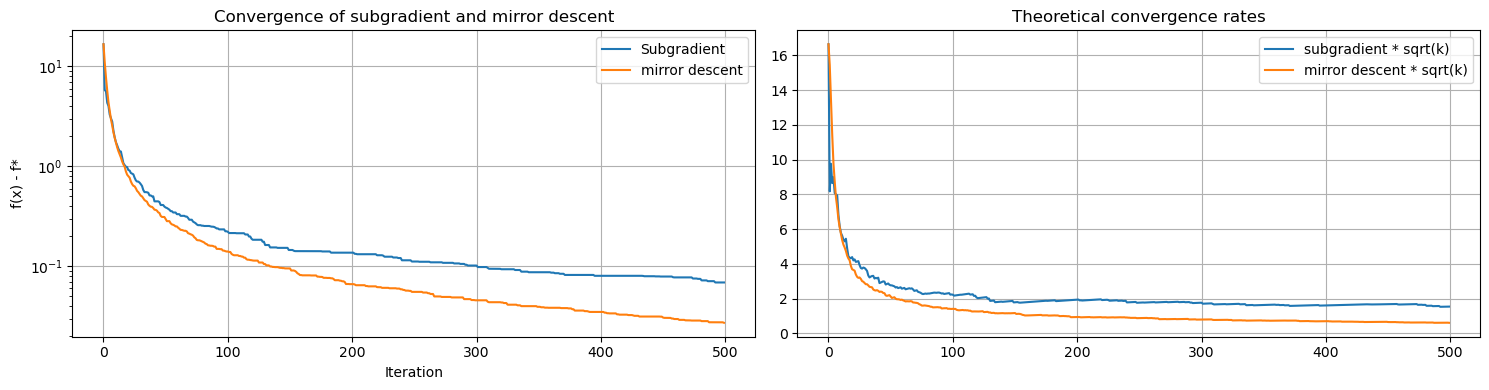

In [7]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(15, 4), sharex=True
)

n = int(100)
m = int(1.5 * n)

max_iters = 500
tol = 1e-6
nmbr_of_runs = 50
x0 = np.ones(n) / n

all_loss_subgrad = []
all_loss_mirror_desc = []

for seed in range(nmbr_of_runs):
    rng = np.random.default_rng(seed)

    A, b, x_true = generate_ax_b_one_norm_params(n, m, rng)

    target_f = lambda x: ax_b_one_norm_objective(A, b, x)
    target_f_subg = lambda x: ax_b_one_norm_objective_subgradient(A, b, x, rng)
    f_sol = target_f(x_true)

    _, history = subgrad_method(
        f=target_f,
        subgrad_f=target_f_subg,
        proj_op=euclidean_projection_onto_simplex,
        step=Descent_step(norm_order=2),
        x0=x0,
        max_iters=max_iters,
        tol=tol,
        history_track_best=True
    )
    all_loss_subgrad.append([f_best for f_best, x in history])

    _, history = mirror_descent_method(
        f=target_f,
        subgrad_f=target_f_subg,
        step=Descent_step(norm_order=np.inf),
        x0=x0,
        max_iters=max_iters,
        tol=tol,
        history_track_best=True
    )
    all_loss_mirror_desc.append([f_best for f_best, x in history])

    all_loss_subgrad[-1] = np.array(all_loss_subgrad[-1]) - f_sol
    all_loss_mirror_desc[-1] = np.array(all_loss_mirror_desc[-1]) - f_sol

all_loss_subgrad = np.array(all_loss_subgrad)
all_loss_mirror_desc = np.array(all_loss_mirror_desc)

median_loss_subgrad = np.median(all_loss_subgrad, axis=0)
median_loss_mirror_desc = np.median(all_loss_mirror_desc, axis=0)

axes[0].plot(median_loss_subgrad, label="Subgradient")
axes[0].plot(median_loss_mirror_desc, label="mirror descent")
axes[0].set_yscale("log")
axes[0].set_ylabel("f(x) - f*")
axes[0].set_xlabel("Iteration")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title("Convergence of subgradient and mirror descent")

axes[1].plot(median_loss_subgrad * (np.arange(1, len(median_loss_subgrad)+1)**0.5), label="subgradient * sqrt(k)")
axes[1].plot(median_loss_mirror_desc * (np.arange(1, len(median_loss_mirror_desc)+1)**0.5), label="mirror descent * sqrt(k)")
axes[1].grid(True)
axes[1].legend()
axes[1].set_title("Theoretical convergence rates")

plt.tight_layout()

## 4. Основной вывод

Хотя оба метода имеют одинаковую асимптотику $ O(1/\sqrt{k}) $, mirror descent демонстрирует существенно лучшую сходимость на симплексе, что подтверждает роль геометрии в методах первого порядка.

## 5. Траектория методов

Теперь посмотрим на траекторию методов. Для этой цели мы сгенерируем следующий набор данных:
- $A \in \mathbb{R}^{6 \times 3}$
- $b \in \mathbb{R}^{6}$
- $\Delta_3 = \{x \in \mathbb{R}^n \mid x \ge 0, \sum_{i=1}^2 x_i = 1 \}$.

Мы уменьшили размерность задачи до $n=3$. Для наглядности траектория метода будет проецироваться в барицентрические координаты. Крайние точки будут проецироваться таким образом:
$$
(1,0,0) \to (0,0) \\
(0,1,0) \to (1,0) \\
(0,0,1) \to \left( \frac{1}{2},\frac{\sqrt{3}}{2} \right)
$$

Тогда любая точка траектории $x = (x_1, x_2, x_3)$ имеет следующий оператор проекции:
$$
x_1 v_1 + x_2 v_2 + x_3 v_3
$$
, где $v_1 = (0,0)$, $v_2 = (1,0)$, $v_3 = \left( \frac{1}{2},\frac{\sqrt{3}}{2} \right)$

In [8]:
def simplex_to_2d(x):
    """
    Map 3D simplex point to 2D barycentric coordinates.
    x must satisfy x1 + x2 + x3 = 1.
    """
    v1 = np.array([0.0, 0.0])
    v2 = np.array([1.0, 0.0])
    v3 = np.array([0.5, np.sqrt(3)/2])

    return x[0]*v1 + x[1]*v2 + x[2]*v3

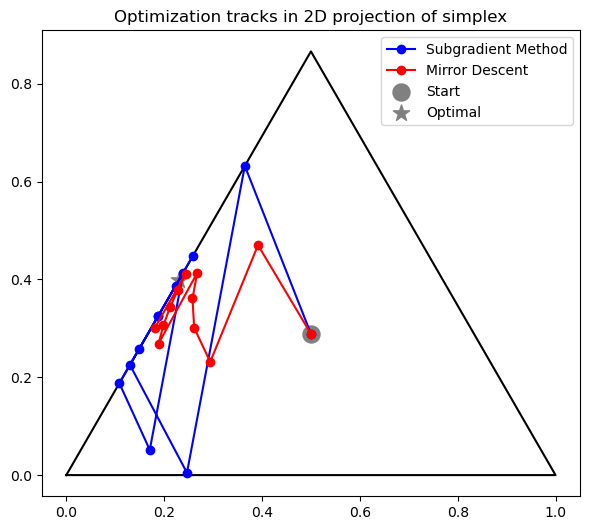

In [9]:
n = 3
m = 6

max_iters = 12
tol = 1e-6
x0 = np.ones(n) / n

track_subgrad = []
track_mirror_desc = []

rng = np.random.default_rng(9)
A, b, x_true = generate_ax_b_one_norm_params(n, m, rng)

target_f = lambda x: ax_b_one_norm_objective(A, b, x)
target_f_subg = lambda x: ax_b_one_norm_objective_subgradient(A, b, x, rng)

_, history = subgrad_method(
    f=target_f,
    subgrad_f=target_f_subg,
    proj_op=euclidean_projection_onto_simplex,
    step=Descent_step(norm_order=2),
    x0=x0,
    max_iters=max_iters,
    tol=tol,
    history_track_best=False
)
track_subgrad = [x for f_best, x in history]

_, history = mirror_descent_method(
    f=target_f,
    subgrad_f=target_f_subg,
    step=Descent_step(norm_order=np.inf),
    x0=x0,
    max_iters=max_iters,
    tol=tol,
    history_track_best=False
)
track_mirror_desc = [x for f_best, x in history]

subgrad_2d = [simplex_to_2d(x) for x in track_subgrad]
mirror_desc_2d = [simplex_to_2d(x) for x in track_mirror_desc]

subgrad_2d = np.array(subgrad_2d)
mirror_desc_2d = np.array(mirror_desc_2d)
opt_2d = simplex_to_2d(x_true)
x0_2d = simplex_to_2d(x0)

fig, ax = plt.subplots(figsize=(6,6))

triangle = np.array([
    simplex_to_2d(np.array([1,0,0])),
    simplex_to_2d(np.array([0,1,0])),
    simplex_to_2d(np.array([0,0,1])),
    simplex_to_2d(np.array([1,0,0]))
])
ax.plot(triangle[:,0], triangle[:,1], 'k-')

ax.plot(subgrad_2d[:,0], subgrad_2d[:,1], c='blue', label='Subgradient Method', marker='o')
ax.plot(mirror_desc_2d[:,0], mirror_desc_2d[:,1], c='red', label='Mirror Descent', marker='o')

ax.scatter(x0_2d[0], x0_2d[1], c='gray', s=150, marker='o', label='Start')
ax.scatter(opt_2d[0], opt_2d[1], c='gray', s=150, marker='*', label='Optimal')

ax.legend()
ax.set_aspect('equal')
ax.set_title("Optimization tracks in 2D projection of simplex")
plt.tight_layout()
plt.show()

Как видим, зеркальный спуск не покидает пределов допустимого множества и сходится к оптимуму по более "постепенной" траектории. Субградиентный же метод вылетает за пределы допустимого множества и показывает резкие скачки.